# What Is Unsupervised Learning?

**Topic:** Unsupervised Learning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from tkh_utils import PALETTE


---
## What you'll explore

By the end of this demo you will be able to:

- **Describe** the core difference between supervised and unsupervised learning
- **Explain** why evaluating unsupervised learning is fundamentally harder than evaluating supervised learning
- **Interpret** a side-by-side comparison of the same data with and without labels

> **Tip:** Look at the side-by-side comparison below. The data is identical — the only difference is whether you know the labels. Notice how that single change transforms the entire task.

---
## How we got here

In **[ml_concepts/02_supervised_vs_unsupervised.ipynb](../ml_concepts/02_supervised_vs_unsupervised.ipynb)** you learned the high-level distinction. This notebook goes deeper: not just *what* changes without labels, but *why* it changes the entire problem formulation — from training, to evaluation, to what "correct" even means.

In **[00_unsupervised_learning_overview.ipynb](00_unsupervised_learning_overview.ipynb)** you saw the two categories of unsupervised learning. This notebook builds the conceptual foundation for all of them.

---
## Why this matters for data science

The supervised mindset — fit a model, measure accuracy, improve — does not transfer cleanly to unsupervised learning. There is no accuracy metric. There is no "right answer" to check against. The cluster assignments your algorithm produces are neither right nor wrong in the same sense.

Understanding this shift is essential. It changes how you evaluate results, how you communicate findings to stakeholders, and how you know when to trust the structure your model has found.

---
## See it in action

The real-world example later in this notebook compares labeled vs. unlabeled data using round, well-separated blobs — the easy case. The chart below shows a trickier shape: two interleaving crescents. With labels, the two groups are obvious. Without labels, your eye can still spot two clusters here — but as you'll see in the next notebook, k-means (which looks for round groups) cannot separate shapes like this the same way.

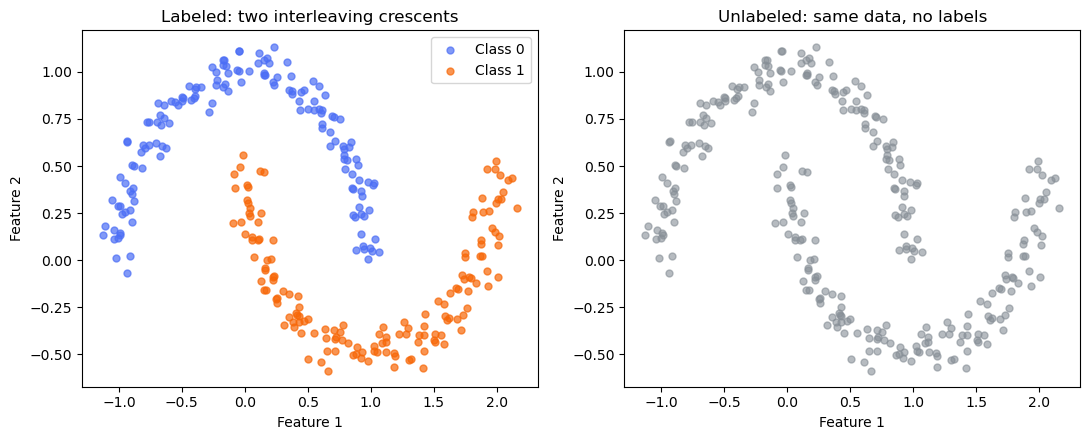

In [2]:
X_moons, y_moons = make_moons(n_samples=300, noise=0.06, random_state=42)
moon_colors = [PALETTE['primary'], PALETTE['secondary']]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for k in range(2):
    mask = y_moons == k
    axes[0].scatter(X_moons[mask, 0], X_moons[mask, 1], color=moon_colors[k],
                     s=25, alpha=0.7, label=f'Class {k}')
axes[0].set_title('Labeled: two interleaving crescents')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].legend()

axes[1].scatter(X_moons[:, 0], X_moons[:, 1], color=PALETTE['muted'], s=25, alpha=0.6)
axes[1].set_title('Unlabeled: same data, no labels')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()


\
---
## What's happening?

**The foreign coin analogy.** Imagine you are handed a pile of foreign coins with no guidebook. You naturally start sorting: by size, then by color, then by markings. You are doing unsupervised learning — grouping objects by similarity without being told what the groups are.

Now imagine you have the same pile but someone has already sorted a reference collection and labeled each coin by country. You can learn to classify coins by matching them to labeled examples. That is supervised learning.

Same data, completely different task.

### The three questions that change

| | Supervised | Unsupervised |
|---|---|---|
| What are we optimizing? | A loss function vs known labels | A structure metric (WCSS, likelihood) |
| How do we evaluate? | Accuracy, F1, RMSE vs ground truth | Silhouette, domain judgment |
| What is "correct"? | Match the label | Coherent, useful, interpretable structure |

### Why evaluation is harder

In supervised learning, you hold out a test set and measure how well predictions match labels. In unsupervised learning, there are no labels to match against. Two perfectly valid runs of k-means on the same data may produce different cluster assignments — and both may be "correct" in the sense of being internally consistent.

This means unsupervised results must be validated differently: with domain knowledge, with downstream task performance, and with stability checks (does the same structure appear on different subsets of the data?).

---
## Real-world example: Labeled vs Unlabeled — The Same Data, Two Tasks

The left chart shows make_blobs data colored by true cluster (supervised view). The right shows the same data as an unsupervised challenge: can you tell how many groups there are?

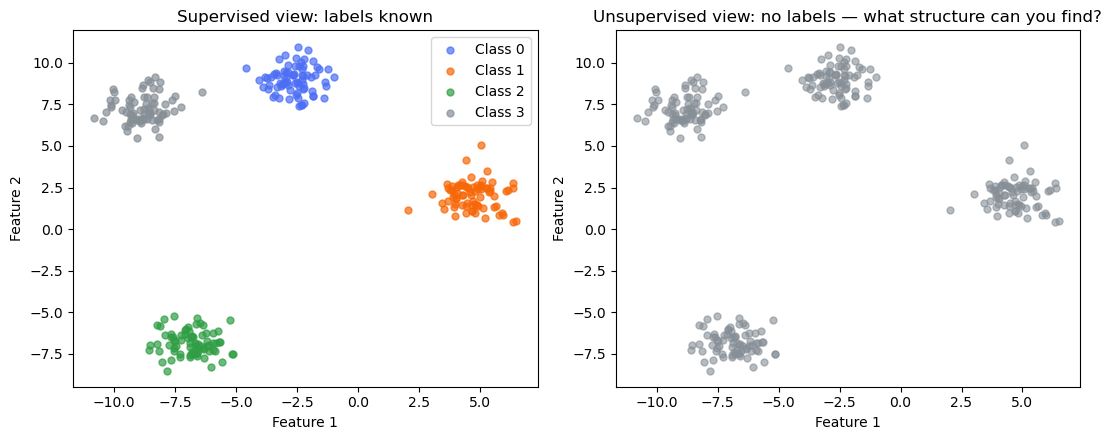

In [3]:
np.random.seed(42)
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.80, random_state=42)
cluster_colors = [PALETTE['primary'], PALETTE['secondary'], PALETTE['accent'], PALETTE['muted']]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for k in range(4):
    mask = y_true == k
    axes[0].scatter(X[mask, 0], X[mask, 1], color=cluster_colors[k], s=25, alpha=0.7, label=f'Class {k}')
axes[0].set_title('Supervised view: labels known')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].legend()

axes[1].scatter(X[:, 0], X[:, 1], color=PALETTE['muted'], s=25, alpha=0.6)
axes[1].set_title('Unsupervised view: no labels — what structure can you find?')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

---
## Key takeaway

> **Unsupervised learning removes the labels and changes the question from "is this prediction correct?" to "is this structure useful?" — and answering the second question requires domain knowledge, not just metrics.**

---
*Next up: 02_kmeans_clustering — the most widely used clustering algorithm, and the right place to start*